In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("covid_19_xl.xlsx")

In [3]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,2019-12-31,0,0,0.0,0,0,0.0,...,1803.987,0.6,597.029,9.59,10.5,30.5,37.746,0.5,64.83,0.498
1,AFG,Asia,Afghanistan,2020-01-01,0,0,0.0,0,0,0.0,...,1803.987,0.6,597.029,9.59,10.5,30.5,37.746,0.5,64.83,0.498
2,AFG,Asia,Afghanistan,2020-01-02,0,0,0.0,0,0,0.0,...,1803.987,0.6,597.029,9.59,10.5,30.5,37.746,0.5,64.83,0.498
3,AFG,Asia,Afghanistan,2020-01-03,0,0,0.0,0,0,0.0,...,1803.987,0.6,597.029,9.59,10.5,30.5,37.746,0.5,64.83,0.498
4,AFG,Asia,Afghanistan,2020-01-04,0,0,0.0,0,0,0.0,...,1803.987,0.6,597.029,9.59,10.5,30.5,37.746,0.5,64.83,0.498


In [4]:
df['date'] = pd.to_datetime(df['date'])

In [5]:
top10 = df.groupby("location")["total_cases"].max().sort_values(ascending=False).head(10)
print(top10)

location
United States    6724667
India            5308014
Brazil           4495183
Russia           1091186
Peru              756412
Colombia          750471
Mexico            688954
South Africa      657627
Spain             640040
Argentina         601700
Name: total_cases, dtype: int64


In [6]:
continent_cases = df.groupby("continent")["total_cases"].max().sort_values(ascending=False)
print(continent_cases)

continent
North America    6724667
Asia             5308014
South America    4495183
Europe           1091186
Africa            657627
Oceania            26861
Name: total_cases, dtype: int64


In [7]:
df["month"] = df["date"].dt.to_period("M")
monthly_deaths = df.groupby("month")["new_deaths"].sum()
print(monthly_deaths)

month
2019-12         0
2020-01       213
2020-02      2702
2020-03     35797
2020-04    189176
2020-05    140149
2020-06    134078
2020-07    166208
2020-08    178627
2020-09    105767
Freq: M, Name: new_deaths, dtype: int64


In [8]:
df['death_rate'] = df["total_deaths"]/ df["total_cases"]
df["death_rate"] = df["death_rate"].fillna(0)

Text(0, 0.5, 'Total Cases')

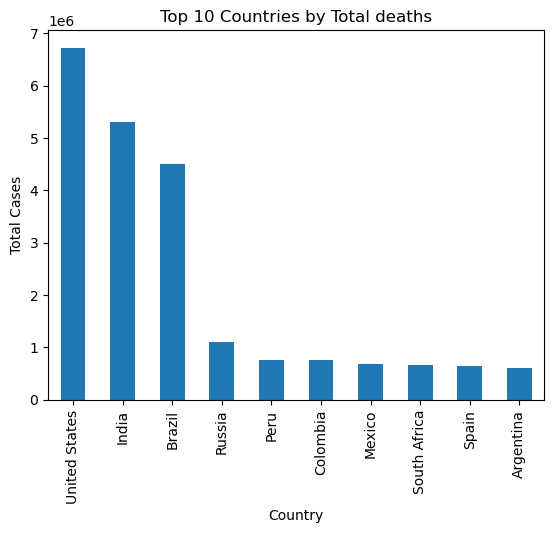

In [9]:
top10.plot(kind="bar")
plt.title("Top 10 Countries by Total deaths")
plt.xlabel("Country")
plt.ylabel("Total Cases")

Text(0.5, 1.0, 'Continent Wise Deaths')

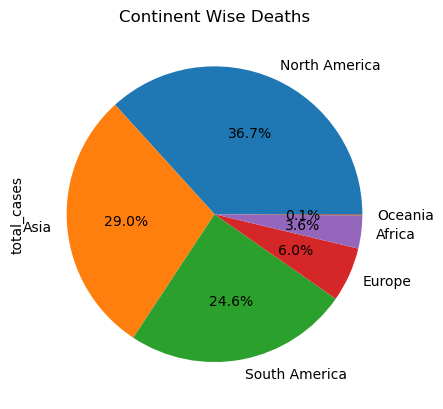

In [10]:
continent_cases.plot(kind="pie", autopct="%1.1f%%")
plt.title("Continent Wise Deaths")

Text(0, 0.5, 'Deaths')

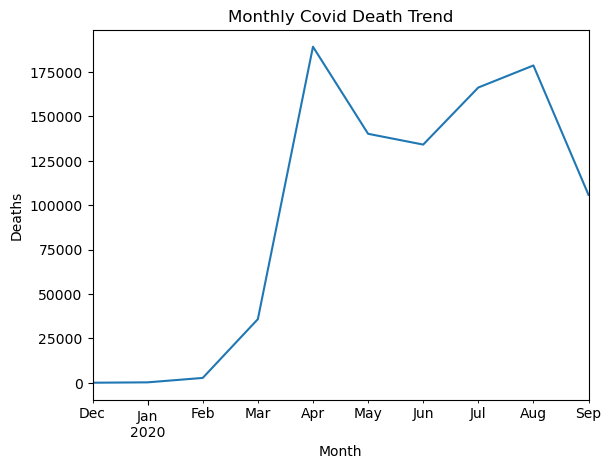

In [11]:
monthly_deaths.plot(kind="line")
plt.title("Monthly Covid Death Trend")
plt.xlabel("Month")
plt.ylabel("Deaths")